# Fake News Detection Data

Fake News detection dataset
Dataset separated in two files:

Fake.csv (23502 fake news article)
True.csv (21417 true news article)
Dataset columns:

Title: title of news article
Text: body text of news article
Subject: subject of news article
Date: publish date of news article

In [1]:

# 1️Import Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

plt.style.use("ggplot")


In [2]:

# Load Dataset Files


# Paths for data 
fake_df = pd.read_csv("C:/Users/theoo/Downloads/DAII_DataSets/Fake news Detection Datasets/Fake.csv")
true_df = pd.read_csv("C:/Users/theoo/Downloads/DAII_DataSets/Fake news Detection Datasets/True.csv")

# Add labels since they are in separate files
fake_df["label"] = "FAKE"
true_df["label"] = "REAL"

# Combine into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle rows (important before modeling later)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nLabel Distribution:\n", df["label"].value_counts())


Dataset Shape: (44898, 5)

Columns: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Label Distribution:
 label
FAKE    23481
REAL    21417
Name: count, dtype: int64


In [3]:
df.head(20)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL
5,Paul Ryan Responds To Dem’s Sit-In On Gun Con...,"On Wednesday, Democrats took a powerful stance...",News,"June 22, 2016",FAKE
6,AWESOME! DIAMOND AND SILK Rip Into The Press: ...,President Trump s rally in FL on Saturday was ...,Government News,"Feb 19, 2017",FAKE
7,STAND UP AND CHEER! UKIP Party Leader SLAMS Ge...,He s been Europe s version of the outspoken Te...,left-news,"Mar 8, 2016",FAKE
8,North Korea shows no sign it is serious about ...,WASHINGTON (Reuters) - The State Department sa...,worldnews,"December 13, 2017",REAL
9,Trump signals willingness to raise U.S. minimu...,(This version of the story corrects the figur...,politicsNews,"May 4, 2016",REAL


In [4]:

# Data Quality Check
print("\nMissing Values Per Column:")
print(df.isna().sum())

print("\nFirst 5 Rows:")
print(df.head())



Missing Values Per Column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

First 5 Rows:
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date label  
0    February 13, 2017  FAKE  
1       April 5, 2017   REAL  
2  September 27, 2017   REAL

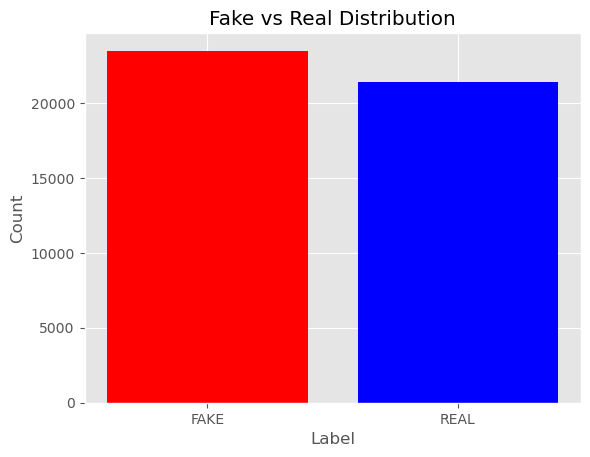

In [5]:

# 5️⃣ Descriptive Analysis

# Ensure consistent order so colors stay aligned
label_counts = df["label"].value_counts().reindex(["FAKE", "REAL"])

plt.figure()
plt.bar(label_counts.index, label_counts.values, color=["red", "blue"])
plt.title("Fake vs Real Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


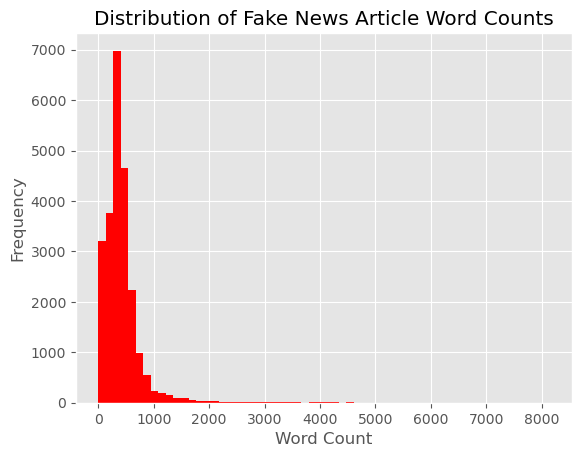

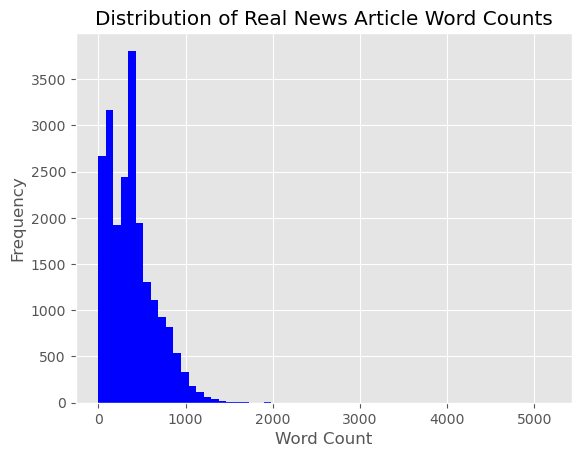

In [6]:
# Create word count column if it doesn't exist
if "text_word_count" not in df.columns:
    df["text"] = df["text"].astype(str)
    df["text_word_count"] = df["text"].str.split().str.len()

# -------------------------------
# Fake News Distribution
# -------------------------------
plt.figure()
df[df["label"] == "FAKE"]["text_word_count"].plot(kind="hist", bins=60, color="red")
plt.title("Distribution of Fake News Article Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


# -------------------------------
# Real News Distribution
# -------------------------------
plt.figure()
df[df["label"] == "REAL"]["text_word_count"].plot(kind="hist", bins=60, color="blue")
plt.title("Distribution of Real News Article Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')



Average Word Count by Label:
label
FAKE    423.197905
REAL    385.640099
Name: text_word_count, dtype: float64


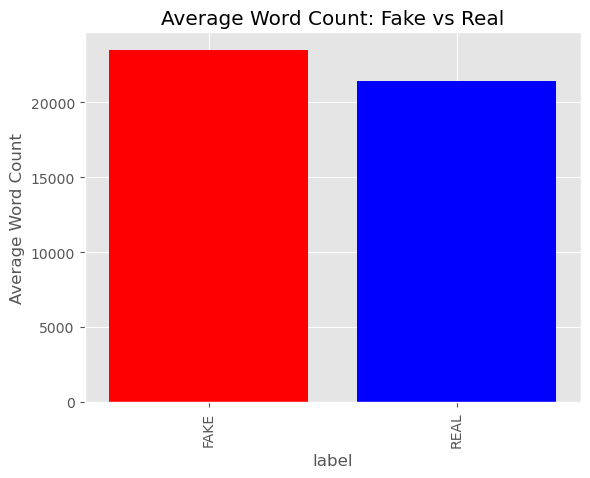

In [7]:
# Update 
avg_wc = df.groupby("label")["text_word_count"].mean()
print("\nAverage Word Count by Label:")
print(avg_wc)

plt.figure()
avg_wc.plot(kind="bar")
plt.bar(label_counts.index, label_counts.values, color=["red", "blue"])
plt.title("Average Word Count: Fake vs Real")
plt.ylabel("Average Word Count")
plt.show()


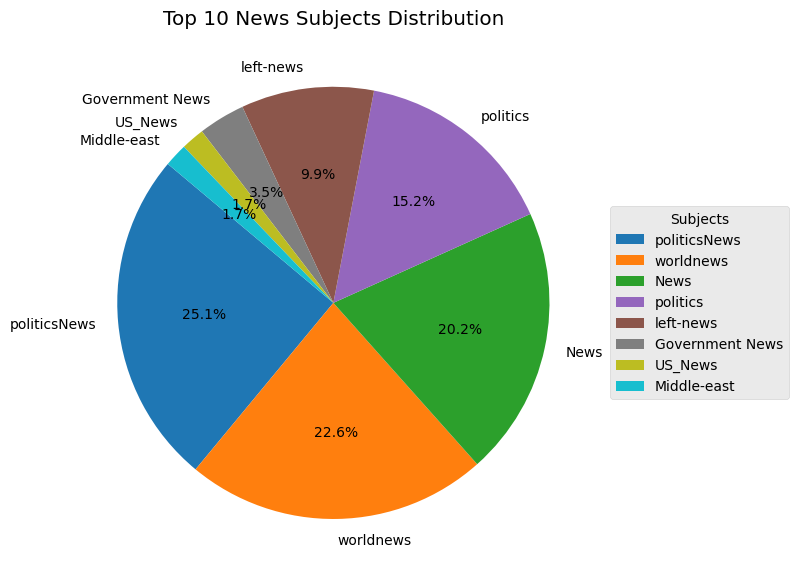

In [11]:
# Update 
if "subject" in df.columns:

    # Get top 10 subjects overall
    subject_counts = df["subject"].value_counts().head(10)

    plt.figure(figsize=(8,8))

    subject_counts.plot(
        kind="pie",
        autopct="%1.1f%%",
        startangle=140,
        cmap="tab10"
    )

    plt.title("Top 10 News Subjects Distribution")
    plt.ylabel("")

    # Move legend outside the chart
    plt.legend(
        subject_counts.index,
        title="Subjects",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()
    plt.show()

C:\Users\theoo\AppData\Local\Temp\ipykernel_16916\4126122035.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


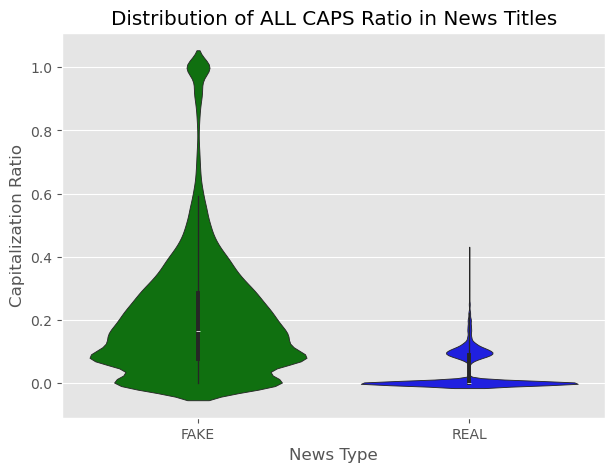

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x="label",
    y="title_caps_ratio",
    palette={"FAKE": "green", "REAL": "blue"}
)

plt.title("Distribution of ALL CAPS Ratio in News Titles")
plt.xlabel("News Type")
plt.ylabel("Capitalization Ratio")

plt.show()

Descriptive Analysis:
The dataset reveals several clear structural patterns in the historical data. The class distribution shows a relatively balanced dataset, with fake news articles slightly outnumbering real news articles, ensuring minimal class imbalance concerns for later modeling. The distribution of article word counts indicates that most articles fall between approximately 200 and 800 words, with a long right-skewed tail extending beyond 2000 words, suggesting the presence of extreme outliers. Subject analysis reveals strong categorical separation: subjects such as News, politics, and left-news appear predominantly in the fake category, whereas politicsNews and worldnews appear almost exclusively in the real category. Additionally, title-level statistics show that fake articles have significantly longer titles on average (≈14.7 words vs. ≈9.95 words) and exhibit a substantially higher proportion of fully capitalized words (≈21% vs. ≈3.8%). These summarized statistical patterns describe how the dataset is structured and highlight measurable differences between fake and real news content.

Diagnostic Analysis: 
The analysis provides insight into why these structural differences may exist. The longer titles and significantly higher ALL-CAPS ratio in fake articles suggest the use of sensationalist or emotionally charged formatting designed to attract attention and increase click-through rates. This stylistic exaggeration aligns with known misinformation dissemination strategies that rely on urgency, shock value, and emotional appeal. Furthermore, the near-exclusive separation of subjects between fake and real categories indicates potential source or publication bias within the dataset. Certain subject labels appear strongly correlated with one class, implying that some news categories or publishers may systematically produce content labeled as fake or real. This suggests that classification performance may be partially driven by topical cues rather than purely linguistic deception patterns, which introduces the risk of label leakage in predictive modeling. Finally, the slightly higher average word count for fake articles may reflect narrative amplification techniques, where misinformation pieces elaborate or repeat claims to enhance perceived credibility. Collectively, these patterns help explain not just what differences exist in the data, but why those differences may occur based on content strategy, subject bias, and stylistic manipulation.